# ATRNet-STAR Adversarial Attack

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_ORDER = ["resnet50", "efficientnet_b3", "vit_b_16"]
MODEL_LABELS = {
    "resnet50": "ResNet-50",
    "efficientnet_b3": "EfficientNet-B3",
    "vit_b_16": "ViT-B/16",
}
MODEL_IDS = {label: model for model, label in MODEL_LABELS.items()}
ATTACK_LABELS = {"fgsm": "FGSM", "pgd": "PGD", "cw": "CW"}
ATTACK_IDS = {label: attack for attack, label in ATTACK_LABELS.items()}
CHANCE_ACC = 100 / 40

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing results/.")

def find_results_dir(root: Path) -> Path:
    candidates = [
        root / "results" / "atrnet_star",
        root / "results" / "attacks" / "atrnet_star",
    ]
    required_files = ("atrnet_trainsum.csv", "atrnet_attksum.csv")
    for candidate in candidates:
        if all((candidate / name).exists() for name in required_files):
            return candidate
    raise FileNotFoundError("Could not find cleaned ATRNet-STAR summary CSVs.")

ROOT = find_project_root()
RESULTS_DIR = find_results_dir(ROOT)
TRAIN_SUMMARY_PATH = RESULTS_DIR / "atrnet_trainsum.csv"
ATTACK_SUMMARY_PATH = RESULTS_DIR / "atrnet_attksum.csv"
OUT_DIR = ROOT / "img" / "sar_atr"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ROOT, RESULTS_DIR

(PosixPath('/Users/george/Downloads/mstar'),
 PosixPath('/Users/george/Downloads/mstar/results/atrnet_star'))

In [2]:
def set_apa_style() -> None:
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
            "font.size": 11,
            "axes.labelsize": 11,
            "axes.titlesize": 12,
            "axes.linewidth": 0.8,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "figure.titlesize": 12,
            "savefig.dpi": 600,
            "savefig.bbox": "tight",
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

def clean_axes(ax: plt.Axes, grid_axis: str = "y") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)
    ax.grid(axis=grid_axis, color="0.88", linewidth=0.6)
    ax.set_axisbelow(True)

def save_figure(fig: plt.Figure, stem: str) -> None:
    png_path = OUT_DIR / f"{stem}.png"
    fig.savefig(png_path, dpi=600)
    print(f"Saved {png_path.relative_to(ROOT)}")

set_apa_style()

In [3]:
clean_by_seed = pd.read_csv(TRAIN_SUMMARY_PATH)
attack_summary = pd.read_csv(ATTACK_SUMMARY_PATH).rename(
    columns={
        "model": "model_label",
        "attack_type": "attack_label",
        "mean": "adv_mean",
        "sd": "adv_sd",
    }
)

clean_by_seed = clean_by_seed[clean_by_seed["model"].isin(MODEL_ORDER)].copy()
for col in ["seed", "test_acc"]:
    clean_by_seed[col] = pd.to_numeric(clean_by_seed[col], errors="coerce")
clean_by_seed["model"] = pd.Categorical(clean_by_seed["model"], MODEL_ORDER, ordered=True)
clean_by_seed["model_label"] = clean_by_seed["model"].astype(str).map(MODEL_LABELS)
clean_by_seed["clean_accuracy_pct"] = clean_by_seed["test_acc"] * 100
clean_by_seed = clean_by_seed.sort_values(["model", "seed"])

for col in ["epsilon", "adv_mean", "adv_sd", "n"]:
    attack_summary[col] = pd.to_numeric(attack_summary[col], errors="coerce")
attack_summary["model"] = attack_summary["model_label"].map(MODEL_IDS)
attack_summary["attack_type"] = attack_summary["attack_label"].map(ATTACK_IDS)
attack_summary["success_mean"] = 100 - attack_summary["adv_mean"]
attack_summary["success_sd"] = attack_summary["adv_sd"]
attack_summary["model"] = pd.Categorical(attack_summary["model"], MODEL_ORDER, ordered=True)
attack_summary = attack_summary.sort_values(["model", "attack_type", "epsilon"])

print(f"Clean rows loaded: {len(clean_by_seed)} from {TRAIN_SUMMARY_PATH.relative_to(ROOT)}")
print(f"Attack summary rows loaded: {len(attack_summary)} from {ATTACK_SUMMARY_PATH.relative_to(ROOT)}")
print("Models:", list(clean_by_seed["model"].dropna().astype(str).unique()))
print("Attack settings:")
display(attack_summary[["attack_label", "epsilon", "n"]])

Clean rows loaded: 15 from results/atrnet_star/atrnet_trainsum.csv
Attack summary rows loaded: 27 from results/atrnet_star/atrnet_attksum.csv
Models: ['resnet50', 'efficientnet_b3', 'vit_b_16']
Attack settings:


,attack_label,epsilon,n
0,CW,0.00,5
1,FGSM,0.01,5
2,FGSM,0.02,5
3,FGSM,0.05,5
4,FGSM,0.10,5
5,PGD,0.01,5
6,PGD,0.02,5
7,PGD,0.05,5
8,PGD,0.10,5
9,CW,0.00,5


## Summary
The tables below report mean and std deviation across the five seeds.

In [4]:
clean_summary = (
    clean_by_seed.groupby(["model", "model_label"], observed=True)["clean_accuracy_pct"]
    .agg(mean="mean", sd="std", n="count")
    .reset_index()
)

display(clean_summary[["model_label", "mean", "sd", "n"]].round(2))
display(attack_summary[["model_label", "attack_label", "epsilon", "adv_mean", "adv_sd", "success_mean", "success_sd", "n"]].round(2))

,model_label,mean,sd,n
0,ResNet-50,97.69,0.09,5
1,EfficientNet-B3,98.84,0.06,5
2,ViT-B/16,74.71,1.38,5


,model_label,attack_label,epsilon,adv_mean,adv_sd,success_mean,success_sd,n
0,ResNet-50,CW,0.00,97.45,0.55,2.55,0.55,5
1,ResNet-50,FGSM,0.01,42.01,11.40,57.99,11.40,5
2,ResNet-50,FGSM,0.02,11.43,3.30,88.57,3.30,5
3,ResNet-50,FGSM,0.05,2.34,0.25,97.66,0.25,5
4,ResNet-50,FGSM,0.10,2.02,0.51,97.98,0.51,5
5,ResNet-50,PGD,0.01,50.91,14.91,49.09,14.91,5
6,ResNet-50,PGD,0.02,22.11,9.33,77.89,9.33,5
7,ResNet-50,PGD,0.05,2.98,0.42,97.02,0.42,5
8,ResNet-50,PGD,0.10,2.02,0.29,97.98,0.29,5
9,EfficientNet-B3,CW,0.00,98.78,0.07,1.22,0.07,5


## Baseline Accuracy

This figure establishes that the models were competent before attack.

Saved img/attack_clean_accuracy_apa.png


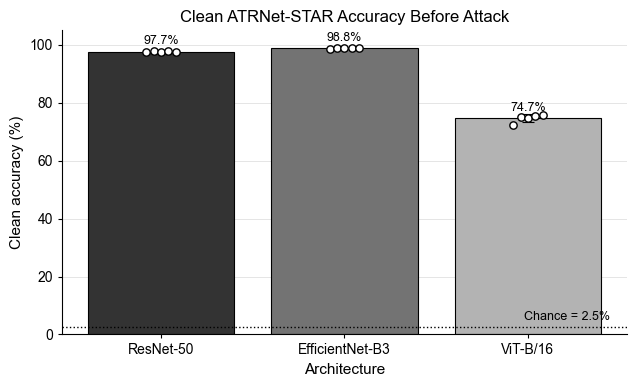

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
x = np.arange(len(clean_summary))
colors = ["0.20", "0.45", "0.70"]

ax.bar(
    x,
    clean_summary["mean"],
    yerr=clean_summary["sd"],
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    error_kw={"elinewidth": 0.8, "capthick": 0.8},
)

for idx, model in enumerate(MODEL_ORDER):
    vals = clean_by_seed.loc[clean_by_seed["model"].astype(str) == model, "clean_accuracy_pct"].to_numpy()
    jitter = np.linspace(-0.08, 0.08, len(vals))
    ax.scatter(np.full(len(vals), idx) + jitter, vals, color="white", edgecolor="black", s=28, zorder=3)

for idx, row in clean_summary.iterrows():
    ax.text(idx, row["mean"] + 1.5, f"{row['mean']:.1f}%", ha="center", va="bottom", fontsize=9)

ax.axhline(CHANCE_ACC, color="black", linestyle=":", linewidth=1.0)
ax.text(2.45, CHANCE_ACC + 1.4, "Chance = 2.5%", ha="right", va="bottom", fontsize=9)
ax.set_xticks(x, clean_summary["model_label"])
ax.set_ylabel("Clean accuracy (%)")
ax.set_xlabel("Architecture")
ax.set_ylim(0, 105)
ax.set_title("Clean ATRNet-STAR Accuracy Before Attack")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "attack_clean_accuracy_apa")
plt.show()

## FGSM and PGD robustness under adversarial attack

Adversarial accuracy given increases in perturbation budget. Accuracy collapses toward random chance at larger epsilon values across all architectures.

Saved img/attack_fgsm_pgd_curves_apa.png


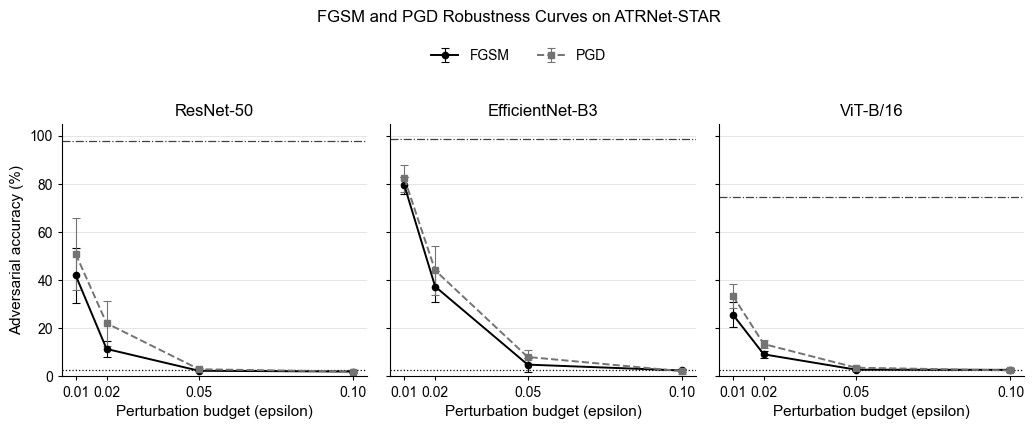

In [6]:
curve_summary = attack_summary[attack_summary["attack_type"].isin(["fgsm", "pgd"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8), sharey=True)
styles = {
    "fgsm": {"color": "black", "marker": "o", "linestyle": "-", "label": "FGSM"},
    "pgd": {"color": "0.45", "marker": "s", "linestyle": "--", "label": "PGD"},
}

for idx, (ax, model) in enumerate(zip(axes, MODEL_ORDER, strict=True)):
    rows_for_model = curve_summary[curve_summary["model"].astype(str) == model]
    for attack_type in ["fgsm", "pgd"]:
        rows = rows_for_model[rows_for_model["attack_type"] == attack_type].sort_values("epsilon")
        ax.errorbar(
            rows["epsilon"],
            rows["adv_mean"],
            yerr=rows["adv_sd"],
            capsize=3,
            linewidth=1.4,
            markersize=4.5,
            elinewidth=0.8,
            capthick=0.8,
            **styles[attack_type],
        )

    clean_acc = clean_summary.loc[clean_summary["model"].astype(str) == model, "mean"].iloc[0]
    ax.axhline(clean_acc, color="0.25", linestyle="-.", linewidth=0.9)
    ax.axhline(CHANCE_ACC, color="black", linestyle=":", linewidth=0.9)

    if idx == 0:
        ax.set_ylabel("Adversarial accuracy (%)")
    ax.set_xlabel("Perturbation budget (epsilon)")
    ax.set_title(MODEL_LABELS[model])
    ax.set_xticks([0.01, 0.02, 0.05, 0.10], ["0.01", "0.02", "0.05", "0.10"])
    ax.set_ylim(0, 105)
    clean_axes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("FGSM and PGD Robustness Curves on ATRNet-STAR", y=1.12)
fig.tight_layout()
save_figure(fig, "attack_fgsm_pgd_curves_apa")
plt.show()

## Adversarial attack at the highest perturbation budget

Attack success rate is `1 - adversarial accuracy`. At `epsilon = 0.10`, FGSM and PGD both succeed on approximately 97% of test examples across architectures.

Saved img/attack_success_eps010_apa.png


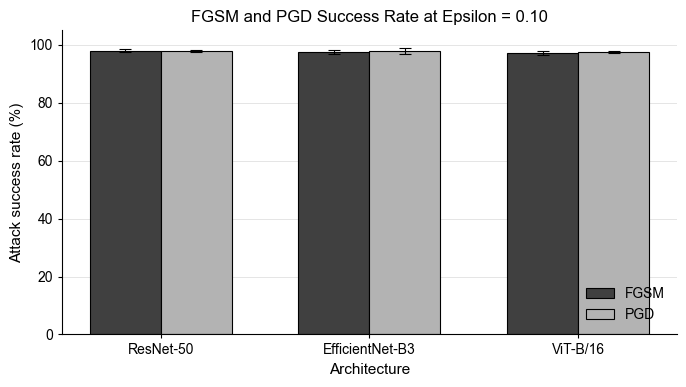

In [7]:
high_eps = attack_summary[
    attack_summary["attack_type"].isin(["fgsm", "pgd"]) & (attack_summary["epsilon"] == 0.10)
].copy()

fig, ax = plt.subplots(figsize=(7.0, 4.0))
x = np.arange(len(MODEL_ORDER))
width = 0.34
offsets = {"fgsm": -width / 2, "pgd": width / 2}
colors = {"fgsm": "0.25", "pgd": "0.70"}

for attack_type in ["fgsm", "pgd"]:
    rows = high_eps[high_eps["attack_type"] == attack_type].set_index("model").loc[MODEL_ORDER]
    ax.bar(
        x + offsets[attack_type],
        rows["success_mean"],
        width=width,
        yerr=rows["success_sd"],
        capsize=4,
        label=ATTACK_LABELS[attack_type],
        color=colors[attack_type],
        edgecolor="black",
        linewidth=0.8,
        error_kw={"elinewidth": 0.8, "capthick": 0.8},
    )

ax.set_xticks(x, [MODEL_LABELS[model] for model in MODEL_ORDER])
ax.set_ylabel("Attack success rate (%)")
ax.set_xlabel("Architecture")
ax.set_ylim(0, 105)
ax.set_title("FGSM and PGD Success Rate at Epsilon = 0.10")
ax.legend(frameon=False, loc="lower right")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "attack_success_eps010_apa")
plt.show()

## CW Attack Result

CW behaved differently from FGSM and PGD in this run. Under the chosen CW settings, it had little effect on ResNet-50 and EfficientNet-B3 and only a modest effect on ViT-B/16.

TODO: retrain/reval ENET-B3

Saved img/attack_cw_accuracy_apa.png


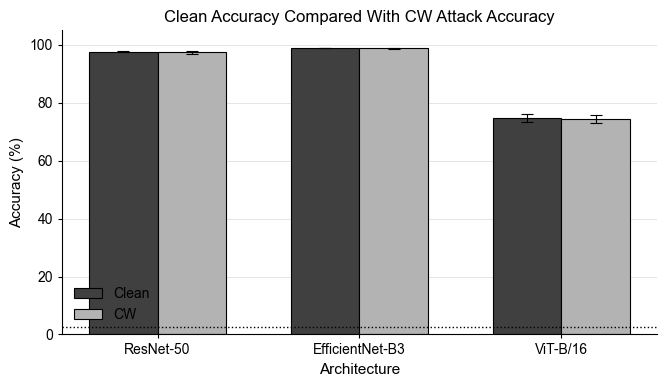

In [8]:
cw_summary = attack_summary[attack_summary["attack_type"] == "cw"].copy()

fig, ax = plt.subplots(figsize=(6.8, 4.0))
x = np.arange(len(MODEL_ORDER))
width = 0.34

clean_rows = clean_summary.set_index("model").loc[MODEL_ORDER]
cw_rows = cw_summary.set_index("model").loc[MODEL_ORDER]

ax.bar(
    x - width / 2,
    clean_rows["mean"],
    width=width,
    yerr=clean_rows["sd"],
    capsize=4,
    label="Clean",
    color="0.25",
    edgecolor="black",
    linewidth=0.8,
    error_kw={"elinewidth": 0.8, "capthick": 0.8},
)
ax.bar(
    x + width / 2,
    cw_rows["adv_mean"],
    width=width,
    yerr=cw_rows["adv_sd"],
    capsize=4,
    label="CW",
    color="0.70",
    edgecolor="black",
    linewidth=0.8,
    error_kw={"elinewidth": 0.8, "capthick": 0.8},
)

ax.axhline(CHANCE_ACC, color="black", linestyle=":", linewidth=1.0)
ax.set_xticks(x, [MODEL_LABELS[model] for model in MODEL_ORDER])
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Architecture")
ax.set_ylim(0, 105)
ax.set_title("Clean Accuracy Compared With CW Attack Accuracy")
ax.legend(frameon=False, loc="lower left")
clean_axes(ax)
fig.tight_layout()
save_figure(fig, "attack_cw_accuracy_apa")
plt.show()